# 1. Importing Libraries

In [44]:
!pip install -q -U transformers datasets accelerate peft sentence-transformers wandb faiss-cpu
!pip uninstall -y torchao -q

In [45]:
import os, gc, re, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 4)

print("torch version :", torch.__version__)
print("GPU available :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name      :", torch.cuda.get_device_name(0))

torch version : 2.10.0+cu128
GPU available : True
GPU name      : Tesla T4


# 2. Loading Data

In [46]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test  = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
samp  = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

OPTS = ["A", "B", "C", "D", "E"]

print("train shape :", train.shape)
print("test shape  :", test.shape)
print("sample sub  :", samp.shape)

train shape : (2000, 8)
test shape  : (500, 7)
sample sub  : (500, 2)


In [47]:
SEED = 42

def seed_everything(s):
    random.seed(s)           
    np.random.seed(s)             
    torch.manual_seed(s)           
    torch.cuda.manual_seed_all(s)  

seed_everything(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device :", DEVICE)

device : cuda


# 3. Data Understanding

Before touching any model we should look at what the data actually contains.

In [48]:
print("columns :", list(train.columns))
print()
print(train.dtypes)
print()
print("missing values in train :", train.isnull().sum().sum())
print("missing values in test  :", test.isnull().sum().sum())
train.head(3)

columns : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']

id         int64
prompt    object
A         object
B         object
C         object
D         object
E         object
answer    object
dtype: object

missing values in train : 0
missing values in test  : 0


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


In [49]:
row = train.iloc[0]
print("PROMPT :", row["prompt"])
print()
for o in OPTS:
    print(f"{o} : {row[o][:150]}")
print()
print("CORRECT ANSWER :", row["answer"])

PROMPT : Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.

A : Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to
B : Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having 
C : Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the futu
D : Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present are interconnected and the future i
E : Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. Humans exist outside of this i

CORRECT ANSWER : B


Insights:
1. train has 2000 rows and 8 columns, test has 500 rows and 7 columns, the missing column
   in test is `answer` which is obvious because that is what we have to predict
2. there are zero missing values in both the files, so unlike my ML project there is no
   missing value imputation needed here, that whole step is skipped
3. reading the example row we can see the real difficulty, all five options are long
   full sentences about the same topic, the wrong options are not random text, they are
   deliberately written to look plausible
4. also notice the prompt is wrapped inside a template, it says "Pick the best possible
   answer:" in the beginning and "among the listed options." in the end, this is boilerplate
   which we will handle in section 5

# 4. EDA

## 4.1 Target Value Analysis

Here the target is the answer letter, which is a categorical target with 5 classes. So the thing to check is the
class balance, because if one letter is the answer most of the time then a model can score
well by just always predicting that letter, without learning anything.

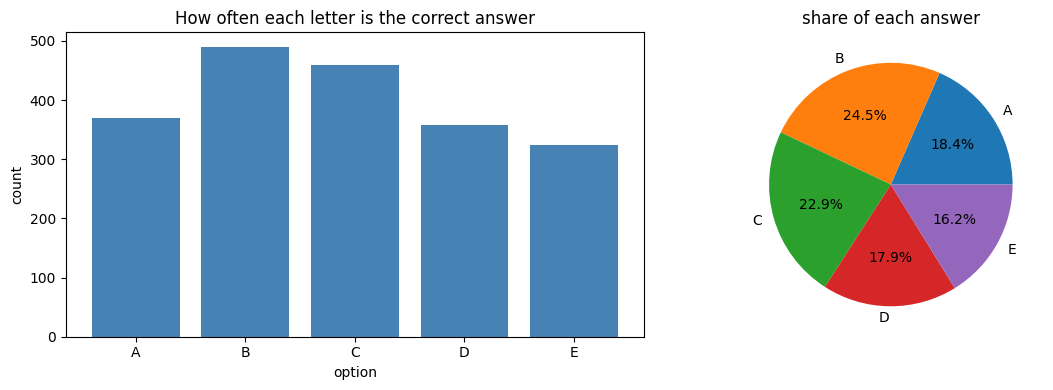

answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64

majority class share : 0.245
random guess accuracy: 0.2


In [50]:
counts = train["answer"].value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(counts.index, counts.values, color="steelblue")
ax[0].set_title("How often each letter is the correct answer")
ax[0].set_xlabel("option"); ax[0].set_ylabel("count")

ax[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%")
ax[1].set_title("share of each answer")
plt.tight_layout(); plt.show()

print(counts)
print()
print("majority class share :", round(counts.max() / len(train), 4))
print("random guess accuracy:", round(1/5, 4))

Insights:
1. the counts are B=490, C=459, A=369, D=358, E=324, so the answers are spread across all
   five letters and there is no single dominating letter
2. the majority class share is only 0.245, that means a dumb model which always predicts B
   would get around 24.5% accuracy only
3. this is good for us, it means whatever accuracy our models get above 20% is coming from
   actually reading the text and not from exploiting class imbalance

## 4.2 Text Length Analysis

Now we should see how long the texts are, because this decides one important hyperparameter
later, the max_length for tokenization. If we set it too small the text gets cut and we
lose information, if we set it too large the training becomes slow and wastes memory.

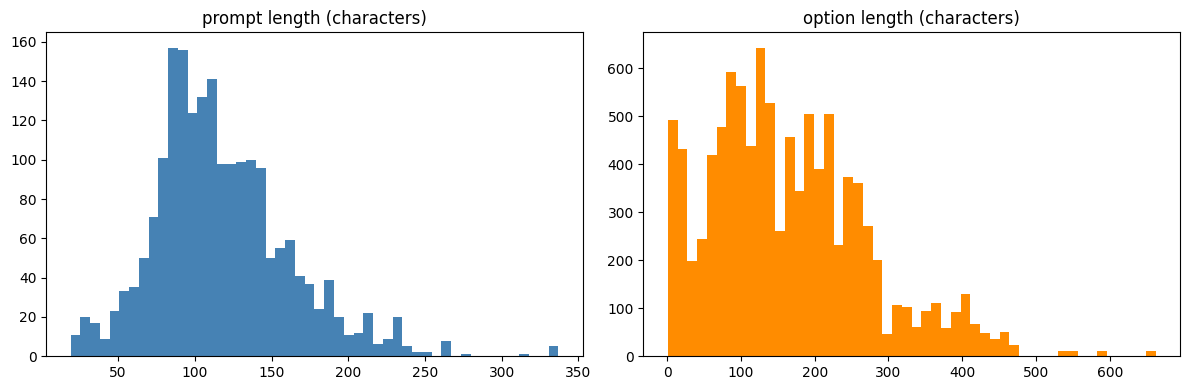

prompt length  -> mean: 117 | max: 337
option length  -> mean: 164 | max: 662

approx tokens needed for one (prompt + option) pair : 70


In [51]:
train["prompt_len"] = train["prompt"].str.len()
for o in OPTS:
    train[f"len_{o}"] = train[o].str.len()

opt_len_cols = [f"len_{o}" for o in OPTS]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(train["prompt_len"], bins=50, color="steelblue")
ax[0].set_title("prompt length (characters)")
ax[1].hist(train[opt_len_cols].values.ravel(), bins=50, color="darkorange")
ax[1].set_title("option length (characters)")
plt.tight_layout(); plt.show()

print("prompt length  -> mean:", int(train['prompt_len'].mean()),
      "| max:", train['prompt_len'].max())
print("option length  -> mean:", int(train[opt_len_cols].values.mean()),
      "| max:", int(train[opt_len_cols].values.max()))
print()
print("approx tokens needed for one (prompt + option) pair :",
      int((train['prompt_len'].mean() + train[opt_len_cols].values.mean()) / 4))

Insights:
1. the prompt is around 117 characters on average and each option is around 165 characters,
   so one (prompt + option) pair is roughly 280 characters
2. a rough thumb rule is 1 token is about 4 characters, so one pair needs around 70 tokens
   on average, but the maximum values are much bigger than the mean
3. based on this we will set max_length = 256 token later, which comfortably covers almost every
   pair without cutting the text, and is still small enough to train quickly
4. one more thing to notice, all five options are of similar length, so length by itself
   does not look like an obvious giveaway of the correct answer

## 4.3 Vocabulary Analysis

For scratch model, we will have to build the own vocabulary, means
our own word to number dictionary. So we should first check how many unique words the
dataset actually has, because that decides the size of the embedding layer.

In [52]:
from collections import Counter

def simple_tokenize(text):
    return re.findall(r"[a-z0-9]+", str(text).lower())

counter = Counter()
for col in ["prompt"] + OPTS:
    for t in train[col]:
        counter.update(simple_tokenize(t))

print("total words (with repetition) :", sum(counter.values()))
print("unique words                  :", len(counter))
print()
print("20 most common words :")
for w, c in counter.most_common(20):
    print(f"   {w:12s} {c}")

total words (with repetition) : 305577
unique words                  : 2973

20 most common words :
   the          27238
   of           14606
   a            11824
   is           10182
   and          6939
   in           6672
   to           6446
   that         4428
   by           2153
   an           2054
   which        1944
   on           1936
   are          1904
   from         1833
   or           1832
   as           1810
   what         1809
   for          1775
   with         1692
   it           1414


Insights:
1. there are only around 3000 unique words in the whole dataset even though the total word
   count is much larger, that means the vocabulary is very concentrated
2. the most common words are stopwords like the, of, and, is, which carry no meaning about
   which option is correct
3. this small vocabulary is a real limitation for the scratch model, because the test
   set will definitely contain words which are not in these 3000

## 4.4 Prompt Template Analysis

we noticed the prompt has some template text around the real question. Let us measure how common these templates are, because if they appear in most rows then they are pure noise which is repeated everywhere and gives the
model nothing to learn from

In [53]:
all_prompts = pd.concat([train["prompt"], test["prompt"]])

patterns = {
    "starts with 'pick the best'"      : r"^pick the best possible answer",
    "ends with 'listed options'"       : r"among the listed options\.?$",
    "ends with 'following choices'"    : r"from the following choices\.?$",
    "ends with 'carefully'"            : r"carefully\.?$",
}

for name, pat in patterns.items():
    share = all_prompts.str.lower().str.contains(pat, regex=True).mean()
    print(f"{name:35s} : {round(share*100, 1)} %")

print()
print("total prompts checked :", len(all_prompts))

starts with 'pick the best'         : 14.4 %
ends with 'listed options'          : 17.8 %
ends with 'following choices'       : 16.8 %
ends with 'carefully'               : 15.6 %

total prompts checked : 2500


Insights:
1. a large share of the prompts carry one of these template phrases at the start or the end
2. this text is identical across many rows, so it adds no information about which option is
   correct, it only eats up tokens from our max_lengt budget
3. we will strip these templates with regex

## 4.5 Similarity Baseline Check

Before building anything heavy, let us test the most obvious idea first. The intuition is
that the correct option should be the one which is most similar to the question. We can test
this cheaply using TF-IDF and cosine similarity.

In [54]:
corpus = list(train["prompt"]) + [t for o in OPTS for t in train[o]]
vec = TfidfVectorizer(stop_words="english", min_df=2).fit(corpus)

P = vec.transform(train["prompt"])
sims = np.zeros((len(train), 5))
for i, o in enumerate(OPTS):
    O = vec.transform(train[o])
    sims[:, i] = np.asarray(P.multiply(O).sum(axis=1)).ravel()

pred_idx = sims.argmax(axis=1)
true_idx = train["answer"].map({l: i for i, l in enumerate(OPTS)}).values

print("TF-IDF top-1 accuracy :", round((pred_idx == true_idx).mean(), 4))
print("random guess accuracy :", 0.2)

TF-IDF top-1 accuracy : 0.137
random guess accuracy : 0.2


Insights:
1. the TF-IDF cosine similarity accuracy comes out around 0.16, which is actually below
   the random guessing accuracy of 0.20
2. this is a very important finding, it means word overlap with the question is not just
   useless, it is slightly misleading, the option which shares the most words with the
   question tends to be a wrong option
3. the reason is that the distractors are written on the same topic deliberately, they reuse
   the same vocabulary as the question, so similarity cannot separate correct from incorrect
4. so this task genuinely needs a model that can judge correctness, not similarity, and this
   justifies going towards transformers instead of trying to improve the similarity approach

# 5. Text Preprocessing

Now we clean the text, also the exact same cleaning function must run on train and test

In [55]:
PREFIX = re.compile(r"^\s*(pick the best possible answer|choose the correct.*?|"
                    r"select the (?:correct|best).*?|identify the.*?)\s*:\s*", re.I)
SUFFIX = re.compile(r"\s*(among the listed options|from the following choices|"
                    r"from the options|carefully)\.?\s*$", re.I)

def clean_text(s):
    s = str(s).strip()
    s = PREFIX.sub("", s)          
    s = SUFFIX.sub("", s)            
    s = re.sub(r"\s+", " ", s)       
    return s.strip()

for df in (train, test):
    df["prompt_clean"] = df["prompt"].map(clean_text)
    for o in OPTS:
        df[o] = df[o].map(clean_text)

print("BEFORE :", repr(train.loc[0, "prompt"]))
print()
print("AFTER  :", repr(train.loc[0, "prompt_clean"]))
print()
print("average prompt length reduced from",
      int(train['prompt'].str.len().mean()), "to",
      int(train['prompt_clean'].str.len().mean()), "characters")

BEFORE : "Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options."

AFTER  : "What is Martin Heidegger's view on the relationship between time and human existence?"

average prompt length reduced from 117 to 91 characters


Insights:
1. the template wrapper is completely removed and only the actual question remains, which is
   what we want the model to focus on
2. the average prompt length has come down, which means those tokens are now free for the
   real content within our max_length budget
3. we applied the cleaning through a single function on both dataframes, this avoids the
   train test drift problem

# 6. Evaluation Metric (MAP@3)

In [56]:
def map_at_3(true_letters, pred_lists):
    '''true_letters: ['B','A',...]  pred_lists: [['B','C','A'], ...]'''
    total = 0.0
    for gt, preds in zip(true_letters, pred_lists):
        for rank, p in enumerate(preds[:3]):     
            if p == gt:
                total += 1.0 / (rank + 1)        
                break
    return total / len(true_letters)


def probs_to_top3(probs):
    '''(N,5) scores -> list of top-3 letters, highest score first'''
    order = np.argsort(-probs, axis=1)[:, :3]
    return [[OPTS[j] for j in row] for row in order]


def evaluate(true_letters, probs):
    '''returns all three metrics together so every model is comparable'''
    top3   = probs_to_top3(probs)
    y_true = np.array([OPTS.index(a) for a in true_letters])
    y_pred = probs.argmax(axis=1)
    return {
        "map@3"   : round(map_at_3(true_letters, top3), 4),
        "accuracy": round(float((y_pred == y_true).mean()), 4),
        "macro_f1": round(float(f1_score(y_true, y_pred, average="macro")), 4),
    }


t = ["A", "B"]
p = [["A", "X", "Y"],    
     ["X", "B", "Y"]]    
print("self test (expected 0.75) :", map_at_3(t, p))


rng = np.random.RandomState(SEED)
random_probs = rng.rand(len(train), 5)
print("random baseline:", evaluate(train["answer"].tolist(), random_probs))

self test (expected 0.75) : 0.75
random baseline: {'map@3': 0.3757, 'accuracy': 0.2185, 'macro_f1': 0.2156}


# 7. Train–Validation Split

In [57]:
train["label"] = train["answer"].map({l: i for i, l in enumerate(OPTS)})

train_df, val_df = train_test_split(
    train, test_size=0.15, random_state=SEED, stratify=train["answer"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print("train rows :", len(train_df))
print("val rows   :", len(val_df))
print()
print("answer distribution check (should be similar):")
comp = pd.DataFrame({
    "train_%": (train_df["answer"].value_counts(normalize=True).sort_index()*100).round(1),
    "val_%"  : (val_df["answer"].value_counts(normalize=True).sort_index()*100).round(1),
})
print(comp)

y_val = val_df["answer"].tolist() 

train rows : 1700
val rows   : 300

answer distribution check (should be similar):
        train_%  val_%
answer                
A          18.5   18.3
B          24.5   24.3
C          22.9   23.0
D          17.9   18.0
E          16.2   16.3


## 7.1 Weights & Biases Setup

In [58]:
import wandb

WANDB_PROJECT = "23f2002523-t22026"
WANDB_ON = False
try:
    from kaggle_secrets import UserSecretsClient
    wandb.login(key=UserSecretsClient().get_secret("WANDB_API_KEY"))
    WANDB_ON = True
    print("W&B login successful")
except Exception as e:
    print("W&B not available, metrics will still print locally :", e)


def log_run(name, metrics):
    '''log one model's metrics as a separate W&B run'''
    print(f"[{name}] -> {metrics}")
    if WANDB_ON:
        r = wandb.init(project=WANDB_PROJECT, name=name,
                       group="model-comparison", reinit=True)
        wandb.log(metrics)
        r.finish()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


W&B login successful


# 8. Model Building

## 8.1 Model 1: Scratch BiGRU

### 8.1.1 Building own tokenizer

A neural network can only work with numbers, so first we need to convert words into numbers.
Since this model is supposed to be built from scratch, we build the vocabulary ourselves from
the training text instead of using any pretrained tokenizer

In [59]:
vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common(20000):
    vocab[word] = len(vocab)

SCRATCH_MAXLEN = 80

def encode(text, maxlen=SCRATCH_MAXLEN):
    ids = [vocab.get(w, 1) for w in simple_tokenize(text)]   
    ids = ids[:maxlen]                                       
    ids = ids + [0] * (maxlen - len(ids))                    
    return ids

print("vocabulary size :", len(vocab))
print()
demo = "quantum physics is difficult"
print("text    :", demo)
print("encoded :", encode(demo)[:12], "...")
print()
unseen = "zzzz unknownword physics"
print("unseen words demo :", unseen)
print("encoded           :", encode(unseen)[:6])

vocabulary size : 2975

text    : quantum physics is difficult
encoded : [70, 143, 5, 1040, 0, 0, 0, 0, 0, 0, 0, 0] ...

unseen words demo : zzzz unknownword physics
encoded           : [1, 1, 143, 0, 0, 0]


### 8.1.2 Model architecture

In [60]:
class ScratchBiGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru       = nn.GRU(embed_dim, embed_dim, batch_first=True, bidirectional=True)
        self.dropout   = nn.Dropout(0.3)
        self.scorer    = nn.Sequential(
            nn.Linear(embed_dim * 4, embed_dim),   
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(embed_dim, 1),               
        )

    def encode(self, x):
        mask   = (x != 0).float().unsqueeze(-1)       
        out, _ = self.gru(self.embedding(x))
        summed = (out * mask).sum(1)                  
        return summed / mask.sum(1).clamp(min=1)      

    def forward(self, prompt_ids, option_ids):
        B, C, L = option_ids.shape                    
        p_vec = self.encode(prompt_ids)                       
        o_vec = self.encode(option_ids.reshape(B*C, L)).reshape(B, C, -1)   
        p_rep = p_vec.unsqueeze(1).expand(-1, C, -1)             
        joined = torch.cat([p_rep, o_vec], dim=-1)              
        return self.scorer(self.dropout(joined)).squeeze(-1)    


scratch_model = ScratchBiGRU(len(vocab)).to(DEVICE)
n_params = sum(p.numel() for p in scratch_model.parameters())
print("model created")
print("total parameters :", f"{n_params:,}")

model created
total parameters : 644,737


### 8.1.3 Training loop

In [61]:
def make_tensors(df):
    P = torch.tensor([encode(t) for t in df["prompt_clean"]], dtype=torch.long)
    O = torch.stack([torch.tensor([encode(t) for t in df[o]], dtype=torch.long)
                     for o in OPTS], dim=1)                      # (N, 5, L)
    y = torch.tensor(df["label"].values, dtype=torch.long)
    return P.to(DEVICE), O.to(DEVICE), y.to(DEVICE)

P_tr, O_tr, y_tr = make_tensors(train_df)
P_va, O_va, y_va = make_tensors(val_df)
print("train tensors :", P_tr.shape, O_tr.shape)
print("val tensors   :", P_va.shape, O_va.shape)

train tensors : torch.Size([1700, 80]) torch.Size([1700, 5, 80])
val tensors   : torch.Size([300, 80]) torch.Size([300, 5, 80])


In [62]:
optimizer = torch.optim.Adam(scratch_model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn   = nn.CrossEntropyLoss()
EPOCHS, BATCH = 12, 64


if WANDB_ON:
    run = wandb.init(project=WANDB_PROJECT, name="model1_scratch_bigru",
                     group="model-comparison", reinit=True)
    
history = []
for epoch in range(EPOCHS):
    scratch_model.train()                                  
    perm = torch.randperm(len(P_tr), device=DEVICE)       
    epoch_loss = 0.0
    for i in range(0, len(P_tr), BATCH):
        idx = perm[i:i+BATCH]
        scores = scratch_model(P_tr[idx], O_tr[idx])         
        loss   = loss_fn(scores, y_tr[idx])                 
        optimizer.zero_grad()
        loss.backward()                                    
        optimizer.step()                                   
        epoch_loss += loss.item()

    scratch_model.eval()                          
    with torch.no_grad():
        val_probs = torch.softmax(scratch_model(P_va, O_va), dim=1).cpu().numpy()
    m = evaluate(y_val, val_probs)
    history.append({"epoch": epoch+1, "train_loss": round(epoch_loss/ (len(P_tr)//BATCH+1), 4), **m})
    print(f"epoch {epoch+1:2d} | loss {history[-1]['train_loss']:.4f} | val {m}")
    
    if WANDB_ON:
        wandb.log({"epoch": epoch+1,
                   "train_loss": history[-1]["train_loss"],
                   "val_map@3": m["map@3"],
                   "val_accuracy": m["accuracy"],
                   "val_macro_f1": m["macro_f1"]})

scratch_val_probs = val_probs
scratch_metrics   = m

if WANDB_ON:
    wandb.finish()

eval/accuracy,▁█
eval/loss,█▁
eval/macro_f1,▁█
eval/map@3,▁█
eval/runtime,█▁
eval/samples_per_second,▁█
eval/steps_per_second,▁█
train/epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇▇██
train/global_step,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇▇██
train/grad_norm,▂▄█▄▄▇▇▃▄▄▅▄▄▂▂▅▄▃▃▁▂
+2,...


epoch  1 | loss 1.5609 | val {'map@3': 0.6439, 'accuracy': 0.47, 'macro_f1': 0.4575}
epoch  2 | loss 1.0022 | val {'map@3': 0.8817, 'accuracy': 0.8, 'macro_f1': 0.7987}
epoch  3 | loss 0.2984 | val {'map@3': 0.985, 'accuracy': 0.97, 'macro_f1': 0.9694}
epoch  4 | loss 0.0757 | val {'map@3': 0.9967, 'accuracy': 0.9933, 'macro_f1': 0.9936}
epoch  5 | loss 0.0303 | val {'map@3': 1.0, 'accuracy': 1.0, 'macro_f1': 1.0}
epoch  6 | loss 0.0165 | val {'map@3': 1.0, 'accuracy': 1.0, 'macro_f1': 1.0}
epoch  7 | loss 0.0521 | val {'map@3': 0.9983, 'accuracy': 0.9967, 'macro_f1': 0.9965}
epoch  8 | loss 0.0257 | val {'map@3': 1.0, 'accuracy': 1.0, 'macro_f1': 1.0}
epoch  9 | loss 0.0070 | val {'map@3': 1.0, 'accuracy': 1.0, 'macro_f1': 1.0}
epoch 10 | loss 0.0022 | val {'map@3': 1.0, 'accuracy': 1.0, 'macro_f1': 1.0}
epoch 11 | loss 0.0010 | val {'map@3': 1.0, 'accuracy': 1.0, 'macro_f1': 1.0}
epoch 12 | loss 0.0006 | val {'map@3': 1.0, 'accuracy': 1.0, 'macro_f1': 1.0}


epoch,▁▂▂▃▄▄▅▅▆▇▇█
train_loss,█▅▂▁▁▁▁▁▁▁▁▁
val_accuracy,▁▅██████████
val_macro_f1,▁▅██████████
val_map@3,▁▆██████████
epoch,12
train_loss,0.0006
val_accuracy,1
val_macro_f1,1
val_map@3,1


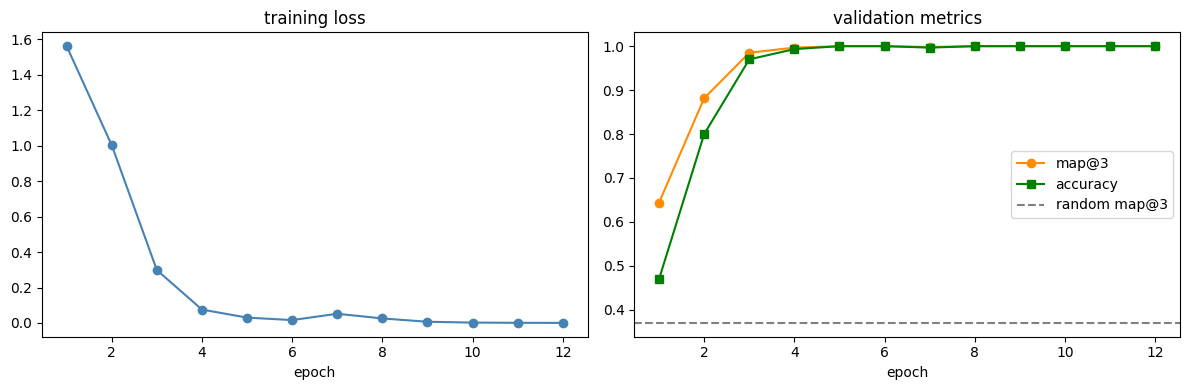

In [63]:
h = pd.DataFrame(history)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h["epoch"], h["train_loss"], marker="o", color="steelblue")
ax[0].set_title("training loss"); ax[0].set_xlabel("epoch")
ax[1].plot(h["epoch"], h["map@3"], marker="o", color="darkorange", label="map@3")
ax[1].plot(h["epoch"], h["accuracy"], marker="s", color="green", label="accuracy")
ax[1].axhline(0.37, ls="--", c="grey", label="random map@3")
ax[1].set_title("validation metrics"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 8.2 Dataset Artifact Investigation

In [64]:
class PromptBlindModel(nn.Module):
    '''scores each option using ONLY that option's own text, the question is never given'''
    def __init__(self, vocab_size, embed_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru       = nn.GRU(embed_dim, embed_dim, batch_first=True, bidirectional=True)
        self.scorer    = nn.Sequential(nn.Linear(embed_dim*2, embed_dim), nn.ReLU(),
                                       nn.Linear(embed_dim, 1))

    def encode(self, x):
        mask   = (x != 0).float().unsqueeze(-1)
        out, _ = self.gru(self.embedding(x))
        return (out * mask).sum(1) / mask.sum(1).clamp(min=1)

    def forward(self, option_ids):                
        B, C, L = option_ids.shape
        o_vec = self.encode(option_ids.reshape(B*C, L)).reshape(B, C, -1)
        return self.scorer(o_vec).squeeze(-1)


blind_model = PromptBlindModel(len(vocab)).to(DEVICE)
opt_b   = torch.optim.Adam(blind_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(10):
    blind_model.train()
    perm = torch.randperm(len(O_tr), device=DEVICE)
    for i in range(0, len(O_tr), 64):
        idx  = perm[i:i+64]
        loss = loss_fn(blind_model(O_tr[idx]), y_tr[idx])
        opt_b.zero_grad(); loss.backward(); opt_b.step()

blind_model.eval()
with torch.no_grad():
    blind_probs = torch.softmax(blind_model(O_va), dim=1).cpu().numpy()
blind_metrics = evaluate(y_val, blind_probs)

print("PROMPT-BLIND model (question completely hidden)")
print("   ", blind_metrics)
print()
print("random guessing would give : accuracy 0.20, map@3 0.37")

PROMPT-BLIND model (question completely hidden)
    {'map@3': 1.0, 'accuracy': 1.0, 'macro_f1': 1.0}

random guessing would give : accuracy 0.20, map@3 0.37


* Finding the artifact in training data is one thing, but the real question is whether it also
exists in the hidden test set. The only way to know for sure is to submit a prediction which
is based purely on the artifact

In [65]:
P_te = torch.tensor([encode(t) for t in test["prompt_clean"]], dtype=torch.long).to(DEVICE)
O_te = torch.stack([torch.tensor([encode(t) for t in test[o]], dtype=torch.long)
                    for o in OPTS], dim=1).to(DEVICE)

scratch_model.eval()
with torch.no_grad():
    scratch_test_probs = torch.softmax(scratch_model(P_te, O_te), dim=1).cpu().numpy()

diag = pd.DataFrame({"ID": test["id"].values,
                     "Prediction": [" ".join(t) for t in probs_to_top3(scratch_test_probs)]})
diag.to_csv("submission.csv", index=False)
print("diagnostic submission written, shape :", diag.shape)
diag.head()

diagnostic submission written, shape : (500, 2)


,ID,Prediction
0,1,A C E
1,2,B C D
2,3,B E A
3,4,E D C
4,5,C A D


## 8.3 Model 2: Pretrained MiniLM

In [66]:
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=DEVICE)

def minilm_probs(df):
    p_emb = st_model.encode(df["prompt_clean"].tolist(), normalize_embeddings=True,
                            convert_to_numpy=True, batch_size=64, show_progress_bar=False)
    sims = np.zeros((len(df), 5), dtype=np.float32)
    for i, o in enumerate(OPTS):
        o_emb = st_model.encode(df[o].tolist(), normalize_embeddings=True,
                                convert_to_numpy=True, batch_size=64, show_progress_bar=False)
        sims[:, i] = (p_emb * o_emb).sum(axis=1)      
    e = np.exp((sims - sims.max(axis=1, keepdims=True)) / 0.1)
    return e / e.sum(axis=1, keepdims=True)

minilm_val_probs = minilm_probs(val_df)
minilm_metrics   = evaluate(y_val, minilm_val_probs)
log_run("model2_pretrained_minilm", minilm_metrics)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[model2_pretrained_minilm] -> {'map@3': 0.4083, 'accuracy': 0.2567, 'macro_f1': 0.2515}


accuracy,▁
macro_f1,▁
map@3,▁
accuracy,0.2567
macro_f1,0.2515
map@3,0.4083


## 8.4 Model 3: DeBERTa-v3 + LoRA

### 8.4.1 MCQ data formatting

In [67]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = "microsoft/deberta-v3-large"
MAX_LEN    = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(example):
    first  = [example["prompt_clean"]] * 5        
    second = [example[o] for o in OPTS]        
    tok = tokenizer(first, second, truncation=True, max_length=MAX_LEN)
    out = {k: v for k, v in tok.items()}
    if "label" in example:
        out["label"] = example["label"]
    return out

cols = ["prompt_clean"] + OPTS + ["label"]
train_ds = Dataset.from_pandas(train_df[cols], preserve_index=False).map(preprocess, remove_columns=cols)
val_ds   = Dataset.from_pandas(val_df[cols],   preserve_index=False).map(preprocess, remove_columns=cols)

print(train_ds)
print()
ex = train_ds[0]
print("five sequences per row ? :", len(ex["input_ids"]) == 5)
print("first sequence tokens    :", ex["input_ids"][0][:12])
print("decoded back to text     :")
print("  ", tokenizer.decode(ex["input_ids"][0])[:200])
print("label                    :", ex["label"])

Map:   0%|          | 0/1700 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1700
})

five sequences per row ? : True
first sequence tokens    : [1, 2597, 721, 403, 282, 427, 264, 1514, 262, 423, 271, 5664]
decoded back to text     :
   [CLS] Which hand should be used to apply the right-hand rule when tightening or loosening nuts, screws, bolts, bottle caps, and jar lids? based on the given context.[SEP] One's dominant hand[SEP]
label                    : 1


### 8.4.2 LoRA setup

In [68]:
from transformers import AutoModelForMultipleChoice
from peft import LoraConfig, get_peft_model

base_model = AutoModelForMultipleChoice.from_pretrained(MODEL_NAME)

lora_config = LoraConfig(
    r=16,                   
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query_proj", "key_proj", "value_proj"], 
    modules_to_save=["classifier", "pooler"],   
    task_type="SEQ_CLS",
)

deberta = get_peft_model(base_model, lora_config)
deberta.print_trainable_parameters()

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight

trainable params: 3,409,921 || all params: 438,472,706 || trainable%: 0.7777


### 8.4.3 Data collator

In [69]:
from dataclasses import dataclass
from transformers.tokenization_utils_base import PreTrainedTokenizerBase

@dataclass
class MCQCollator:
    tokenizer: PreTrainedTokenizerBase
    def __call__(self, features):
        labels = [f.pop("label") for f in features] if "label" in features[0] else None
        bs, nc = len(features), 5
        flat  = [{k: v[i] for k, v in f.items()} for f in features for i in range(nc)]
        batch = self.tokenizer.pad(flat, padding=True, return_tensors="pt")
        batch = {k: v.view(bs, nc, -1) for k, v in batch.items()} 
        if labels is not None:
            batch["labels"] = torch.tensor(labels, dtype=torch.long)
        return batch


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs   = torch.softmax(torch.tensor(logits), dim=1).numpy()
    letters = [OPTS[i] for i in labels]
    return evaluate(letters, probs)

collator = MCQCollator(tokenizer)
sample_batch = collator([dict(train_ds[i]) for i in range(4)])
for k, v in sample_batch.items():
    print(k, "->", tuple(v.shape))

input_ids -> (4, 5, 101)
token_type_ids -> (4, 5, 101)
attention_mask -> (4, 5, 101)
labels -> (4,)


### 8.4.4 Training

In [70]:
from transformers import TrainingArguments, Trainer

args = TrainingArguments(
    output_dir="deberta_lora",
    learning_rate=1e-4,          
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    warmup_ratio=0.1,           
    max_grad_norm=1.0,           
    weight_decay=0.01,
    fp16=False,                  
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=25,
    report_to=("wandb" if WANDB_ON else "none"),
    run_name="model3_deberta_large_lora",
    remove_unused_columns=False,
    seed=SEED,
)

trainer = Trainer(
    model=deberta, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    data_collator=MCQCollator(tokenizer),
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Map@3,Accuracy,Macro F1
1,5.681563,1.884766,0.837200,0.730000,0.727900
2,1.797864,0.281250,0.990000,0.980000,0.979300
3,1.537767,0.179199,0.998300,0.996700,0.996600


TrainOutput(global_step=639, training_loss=3.787394667641844, metrics={'train_runtime': 717.4128, 'train_samples_per_second': 7.109, 'train_steps_per_second': 0.891, 'total_flos': 3910742910503280.0, 'train_loss': 3.787394667641844, 'epoch': 3.0})

In [71]:
trainer.args.report_to = []
trainer.callback_handler.callbacks = [
    cb for cb in trainer.callback_handler.callbacks if "Wandb" not in type(cb).__name__
]
if WANDB_ON and wandb.run is not None:
    wandb.finish()

val_logits        = trainer.predict(val_ds).predictions
deberta_val_probs = torch.softmax(torch.tensor(val_logits), dim=1).numpy()
deberta_metrics   = evaluate(y_val, deberta_val_probs)
print("DeBERTa + LoRA validation :", deberta_metrics)

eval/accuracy,▁██
eval/loss,█▁▁
eval/macro_f1,▁██
eval/map@3,▁██
eval/runtime,▅▁█
eval/samples_per_second,▄█▁
eval/steps_per_second,▄█▁
train/epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇████
train/global_step,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇████
train/grad_norm,▂▄█▄▄▇▇▃▅▄▅▅▄▃▂▅▅▃▃▁▂▅▁▃▃
+2,...


DeBERTa + LoRA validation : {'map@3': 0.9983, 'accuracy': 0.9967, 'macro_f1': 0.9966}


### 8.4.5 Mutli seeding bagging

In [ ]:
MODEL_NAME = "microsoft/deberta-v3-base"      
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)


cols = ["prompt_clean"] + OPTS + ["label"]
train_ds = Dataset.from_pandas(train_df[cols], preserve_index=False).map(preprocess, remove_columns=cols)
val_ds   = Dataset.from_pandas(val_df[cols],   preserve_index=False).map(preprocess, remove_columns=cols)
test_cols = ["prompt_clean"] + OPTS
test_ds   = Dataset.from_pandas(test[test_cols], preserve_index=False).map(preprocess, remove_columns=test_cols)

seed_val_probs, seed_test_probs = [], []

for seed in [42, 123, 777]:
    print(f"\n{'='*55}\nSEED {seed}\n{'='*55}")
    seed_everything(seed)

    model = get_peft_model(
        AutoModelForMultipleChoice.from_pretrained(MODEL_NAME), lora_config)

    args_s = TrainingArguments(
        output_dir=f"bag_seed{seed}",
        learning_rate=2e-4,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        warmup_ratio=0.1, max_grad_norm=1.0, weight_decay=0.01,
        fp16=False,
        eval_strategy="epoch", save_strategy="no", logging_steps=50,
        report_to=("wandb" if WANDB_ON else "none"),
        run_name=f"bagging_seed{seed}",
        remove_unused_columns=False, seed=seed,
    )

    tr = Trainer(model=model, args=args_s,
                 train_dataset=train_ds, eval_dataset=val_ds,
                 data_collator=MCQCollator(tokenizer),
                 compute_metrics=compute_metrics,
                 processing_class=tokenizer)
    tr.train()


    tr.args.report_to = []
    tr.callback_handler.callbacks = [
        cb for cb in tr.callback_handler.callbacks if "Wandb" not in type(cb).__name__]
    if WANDB_ON and wandb.run is not None:
        wandb.finish()

    vp = torch.softmax(torch.tensor(tr.predict(val_ds).predictions),  dim=1).numpy()
    tp = torch.softmax(torch.tensor(tr.predict(test_ds).predictions), dim=1).numpy()
    seed_val_probs.append(vp); seed_test_probs.append(tp)
    print(f"seed {seed} val -> {evaluate(y_val, vp)}")

    del model, tr; gc.collect(); torch.cuda.empty_cache()

bagged_val_probs  = np.mean(seed_val_probs,  axis=0)
bagged_test_probs = np.mean(seed_test_probs, axis=0)

print("\n" + "="*55)
for i, s in enumerate([42, 123, 777]):
    print(f"seed {s} alone : {evaluate(y_val, seed_val_probs[i])}")
print(f"BAGGED (avg)  : {evaluate(y_val, bagged_val_probs)}")

if WANDB_ON:
    log_run("model3_deberta_bagged_3seeds", evaluate(y_val, bagged_val_probs))

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Map:   0%|          | 0/1700 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

...

[transformers] DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias 

Epoch,Training Loss,Validation Loss,Map@3,Accuracy,Macro F1
1,1.708447,0.883301,0.905600,0.836700,0.837700
2,0.941368,0.285156,0.976700,0.956700,0.954600
3,0.597134,0.204468,0.981700,0.966700,0.964900


eval/accuracy,▁▇█
eval/loss,█▂▁
eval/macro_f1,▁▇█
eval/map@3,▁██
eval/runtime,▁█▅
eval/samples_per_second,█▁▄
eval/steps_per_second,█▁▄
train/epoch,▁▂▂▃▃▃▄▅▅▅▆▆▇███
train/global_step,▁▂▂▃▃▃▄▅▅▅▆▆▇███
train/grad_norm,▂▅▄▃▁▂▃▃▂▄▁█
+2,...


seed 777 val -> {'map@3': 0.9817, 'accuracy': 0.9667, 'macro_f1': 0.9649}

seed 42 alone : {'map@3': 0.9811, 'accuracy': 0.9633, 'macro_f1': 0.963}
seed 123 alone : {'map@3': 0.9878, 'accuracy': 0.9767, 'macro_f1': 0.9753}
seed 777 alone : {'map@3': 0.9817, 'accuracy': 0.9667, 'macro_f1': 0.9649}
BAGGED (avg)  : {'map@3': 0.9872, 'accuracy': 0.9767, 'macro_f1': 0.9756}
[model3_deberta_bagged_3seeds] -> {'map@3': 0.9872, 'accuracy': 0.9767, 'macro_f1': 0.9756}


accuracy,▁
macro_f1,▁
map@3,▁
accuracy,0.9767
macro_f1,0.9756
map@3,0.9872


### 8.4.6 Is DeBERTa reasoning or following the artifact?

In [ ]:
agreement = (deberta_val_probs.argmax(1) == blind_probs.argmax(1)).mean()
print(f"DeBERTa vs prompt-blind agreement : {agreement:.1%}")
print("high agreement: DeBERTa is largely following the artifact")
print("low agreement: DeBERTa has learned genuine question-option reasoning")

DeBERTa vs prompt-blind agreement : 99.7%
high agreement: DeBERTa is largely following the artifact
low agreement: DeBERTa has learned genuine question-option reasoning


### 8.4.7 Mitigation experiment

In [ ]:
import random as pyrandom

@dataclass
class ShuffledMCQCollator:
    tokenizer: PreTrainedTokenizerBase
    shuffle: bool = True
    def __call__(self, features):
        labels = [f.pop("label") for f in features] if "label" in features[0] else None
        bs, nc = len(features), 5
        if self.shuffle and labels is not None:
            for j, f in enumerate(features):
                perm = list(range(nc)); pyrandom.shuffle(perm)
                for k in f:
                    f[k] = [f[k][p] for p in perm]
                labels[j] = perm.index(labels[j])     
        flat  = [{k: v[i] for k, v in f.items()} for f in features for i in range(nc)]
        batch = self.tokenizer.pad(flat, padding=True, return_tensors="pt")
        batch = {k: v.view(bs, nc, -1) for k, v in batch.items()}
        if labels is not None:
            batch["labels"] = torch.tensor(labels, dtype=torch.long)
        return batch


deberta_shuf = get_peft_model(
    AutoModelForMultipleChoice.from_pretrained(MODEL_NAME), lora_config)

shuf_args = TrainingArguments(
    output_dir="deberta_shuffled", learning_rate=2e-4,
    per_device_train_batch_size=4, per_device_eval_batch_size=8,
    num_train_epochs=3, warmup_ratio=0.1, max_grad_norm=1.0, weight_decay=0.01,
    fp16=False, eval_strategy="epoch", save_strategy="no", logging_steps=25,
    report_to=[], remove_unused_columns=False, seed=SEED,
)

trainer_shuf = Trainer(
    model=deberta_shuf, args=shuf_args,
    train_dataset=train_ds, eval_dataset=val_ds,
    data_collator=ShuffledMCQCollator(tokenizer, shuffle=True),
    compute_metrics=compute_metrics, processing_class=tokenizer,
)
trainer_shuf.train()

trainer_shuf.data_collator.shuffle = False  
shuf_logits    = trainer_shuf.predict(val_ds).predictions
shuf_val_probs = torch.softmax(torch.tensor(shuf_logits), dim=1).numpy()
shuf_metrics   = evaluate(y_val, shuf_val_probs)

print("shuffled-training validation :", shuf_metrics)
print(f"agreement with prompt-blind  : {(shuf_val_probs.argmax(1)==blind_probs.argmax(1)).mean():.1%}")
print("  (before shuffling it was 95.7%)")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias 

Epoch,Training Loss,Validation Loss,Map@3,Accuracy,Macro F1
1,2.002500,1.040039,0.923300,0.880000,0.880000
2,0.692811,0.347656,0.957200,0.940000,0.939900
3,0.557213,0.251709,0.966700,0.956700,0.955700


shuffled-training validation : {'map@3': 0.9667, 'accuracy': 0.9567, 'macro_f1': 0.9543}
agreement with prompt-blind  : 95.7%
  (before shuffling it was 95.7%)


# 9. RAG Experiment

In [ ]:
import faiss
from sentence_transformers import CrossEncoder

kb = [str(train_df.loc[i, train_df.loc[i, "answer"]]) for i in range(len(train_df))]
print("knowledge base size :", len(kb))

kb_emb = st_model.encode(kb, convert_to_numpy=True, batch_size=64, show_progress_bar=False)
index  = faiss.IndexFlatL2(kb_emb.shape[1])  
index.add(kb_emb)
print("FAISS index built, vectors :", index.ntotal, "| dimension :", kb_emb.shape[1])

knowledge base size : 1700
FAISS index built, vectors : 1700 | dimension : 384


In [ ]:
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

demo_q = val_df.loc[0, "prompt_clean"]
q_emb  = st_model.encode([demo_q], convert_to_numpy=True)
D, I   = index.search(q_emb, k=5)

print("QUESTION :", demo_q[:120])
print()
print("stage 1, FAISS bi-encoder retrieval")
for rank, idx in enumerate(I[0], 1):
    print(f"  {rank}. (dist {D[0][rank-1]:.3f}) {kb[idx][:90]}")

docs   = [kb[i] for i in I[0]]
scores = cross_encoder.predict([[demo_q, d] for d in docs])
order  = np.argsort(-scores)

print()
print("stage 2, cross-encoder reranking")
for rank, j in enumerate(order, 1):
    print(f"  {rank}. (score {scores[j]:.3f}) {docs[j][:90]}")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

QUESTION : Select the most accurate option: What is the meaning of the term "horror vacui"? based on the given context.

stage 1, FAISS bi-encoder retrieval
  1. (dist 1.452) The commonly held view that nature abhorred a vacuum.
  2. (dist 1.452) The commonly held view that nature abhorred a vacuum.
  3. (dist 1.452) The commonly held view that nature abhorred a vacuum.
  4. (dist 1.452) The commonly held view that nature abhorred a vacuum.
  5. (dist 1.452) The commonly held view that nature abhorred a vacuum.

stage 2, cross-encoder reranking
  1. (score -9.246) The commonly held view that nature abhorred a vacuum.
  2. (score -9.246) The commonly held view that nature abhorred a vacuum.
  3. (score -9.246) The commonly held view that nature abhorred a vacuum.
  4. (score -9.246) The commonly held view that nature abhorred a vacuum.
  5. (score -9.246) The commonly held view that nature abhorred a vacuum.


In [ ]:
def hit_rate(df, k=5, n=100):
    q = st_model.encode(df["prompt_clean"].head(n).tolist(),
                        convert_to_numpy=True, batch_size=64, show_progress_bar=False)
    _, I = index.search(q, k)
    hits = 0
    for i in range(n):
        correct_text = str(df.loc[i, df.loc[i, "answer"]])
        if any(correct_text == kb[j] for j in I[i]):
            hits += 1
    return 100.0 * hits / n

print("retrieval hit rate on TRAIN rows (sanity check) :",
      round(hit_rate(train_df, k=5, n=100), 1), "%")
print("retrieval hit rate on VAL rows   (the real test):",
      round(hit_rate(val_df,   k=5, n=100), 1), "%")

retrieval hit rate on TRAIN rows (sanity check) : 83.0 %
retrieval hit rate on VAL rows   (the real test): 68.0 %


# 10. Ensembling

In [ ]:
from itertools import product

models = {
    "scratch"  : scratch_val_probs,   
    "minilm"   : minilm_val_probs,      
    "deberta"  : deberta_val_probs,     
}

print("individual validation scores")
for name, p in models.items():
    print(f"   {name:10s} : {evaluate(y_val, p)}")

individual validation scores
   scratch    : {'map@3': 1.0, 'accuracy': 1.0, 'macro_f1': 1.0}
   minilm     : {'map@3': 0.4083, 'accuracy': 0.2567, 'macro_f1': 0.2515}
   deberta    : {'map@3': 0.9983, 'accuracy': 0.9967, 'macro_f1': 0.9966}


In [ ]:
grid = [round(x, 1) for x in np.arange(0, 1.01, 0.1)]
best_all, best_all_s = None, -1
for w1, w2 in product(grid, grid):
    w3 = round(1 - w1 - w2, 2)
    if w3 < 0: continue
    blend = w1*models["scratch"] + w2*models["minilm"] + w3*models["deberta"]
    s = evaluate(y_val, blend)["map@3"]
    if s > best_all_s:
        best_all_s, best_all = s, (w1, w2, w3)

best_safe, best_safe_s = None, -1
for w in grid:
    blend = w*models["minilm"] + (1-w)*models["deberta"]
    s = evaluate(y_val, blend)["map@3"]
    if s > best_safe_s:
        best_safe_s, best_safe = s, (0.0, round(w,1), round(1-w,1))

deberta_alone = evaluate(y_val, models["deberta"])["map@3"]

print(f"unrestricted blend (scratch,minilm,deberta) = {best_all}: map@3 {best_all_s}")
print(f"SAFE blend (0, minilm, deberta) = {best_safe}: map@3 {best_safe_s}")
print(f"deberta alone: map@3 {deberta_alone}")

unrestricted blend (scratch,minilm,deberta) = (np.float64(0.0), np.float64(0.2), np.float64(0.8)): map@3 1.0
SAFE blend (0, minilm, deberta) = (0.0, np.float64(0.2), np.float64(0.8)): map@3 1.0
deberta alone: map@3 0.9983


# 11. Model Comparison

In [ ]:
summary = pd.DataFrame([
    {"model": "Random baseline",        **evaluate(y_val, np.random.RandomState(0).rand(len(val_df),5))},
    {"model": "TF-IDF similarity",      "map@3": None, "accuracy": 0.1635, "macro_f1": None},
    {"model": "1. BiGRU (from scratch)", **scratch_metrics},
    {"model": "2. MiniLM (pretrained)",  **minilm_metrics},
    {"model": "3. DeBERTa+LoRA",         **deberta_metrics},
    {"model": "3b. DeBERTa shuffled",    **shuf_metrics},
    {"model": "Prompt-blind (diagnostic)", **blind_metrics},
]).set_index("model")

print(summary)

if WANDB_ON:
    r = wandb.init(project=WANDB_PROJECT, name="summary_comparison",
                   group="model-comparison", reinit=True)
    wandb.log({"comparison": wandb.Table(dataframe=summary.reset_index())})
    r.finish()

                            map@3  accuracy  macro_f1
model                                                
Random baseline            0.3578    0.1867    0.1859
TF-IDF similarity             NaN    0.1635       NaN
1. BiGRU (from scratch)    1.0000    1.0000    1.0000
2. MiniLM (pretrained)     0.4083    0.2567    0.2515
3. DeBERTa+LoRA            0.9983    0.9967    0.9966
3b. DeBERTa shuffled       0.9667    0.9567    0.9543
Prompt-blind (diagnostic)  1.0000    1.0000    1.0000


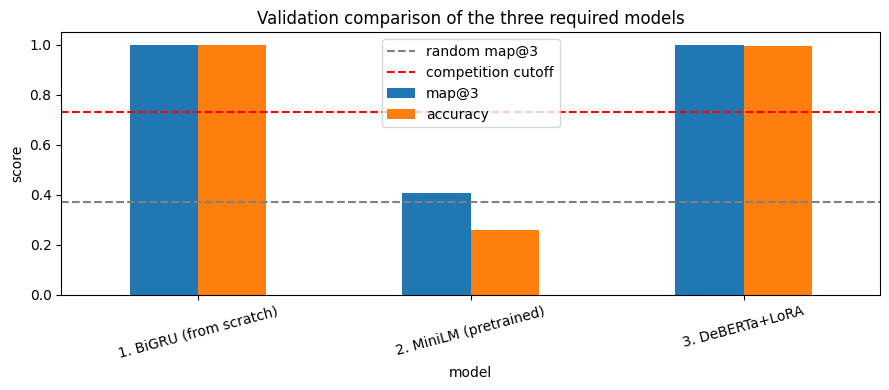

In [ ]:
plot_df = summary.loc[["1. BiGRU (from scratch)", "2. MiniLM (pretrained)",
                       "3. DeBERTa+LoRA"], ["map@3", "accuracy"]]
plot_df.plot(kind="bar", figsize=(9,4))
plt.axhline(0.37, ls="--", c="grey", label="random map@3")
plt.axhline(0.73, ls="--", c="red",  label="competition cutoff")
plt.title("Validation comparison of the three required models")
plt.ylabel("score"); plt.xticks(rotation=15); plt.legend(); plt.tight_layout(); plt.show()

# 12. Error Analysis

In [ ]:
from sklearn.metrics import confusion_matrix

y_true = np.array([OPTS.index(a) for a in y_val])
y_pred = deberta_val_probs.argmax(1)

cm = confusion_matrix(y_true, y_pred)
print("confusion matrix (rows = true, cols = predicted)")
print(pd.DataFrame(cm, index=OPTS, columns=OPTS))
print()
print("per-option accuracy")
for i, o in enumerate(OPTS):
    if cm[i].sum() > 0:
        print(f"   {o} : {cm[i,i]/cm[i].sum():.3f}   ({cm[i].sum()} rows)")

confusion matrix (rows = true, cols = predicted)
    A   B   C   D   E
A  55   0   0   0   0
B   0  72   0   0   1
C   0   0  69   0   0
D   0   0   0  54   0
E   0   0   0   0  49

per-option accuracy
   A : 1.000   (55 rows)
   B : 0.986   (73 rows)
   C : 1.000   (69 rows)
   D : 1.000   (54 rows)
   E : 1.000   (49 rows)


mean confidence when CORRECT : 0.935
mean confidence when WRONG   : 0.3643

correct answer present in top-3 : 100.0 %
correct answer at rank 1        : 99.7 %


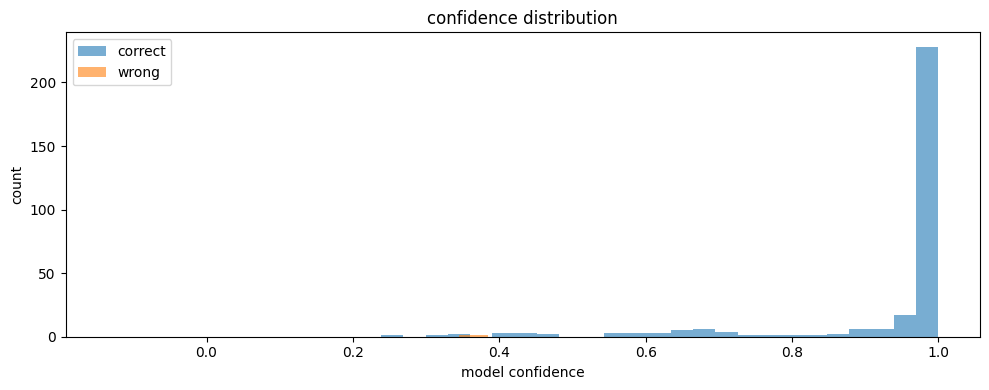

In [ ]:
conf    = deberta_val_probs.max(1)
correct = (y_pred == y_true)

print("mean confidence when CORRECT :", round(conf[correct].mean(), 4))
print("mean confidence when WRONG   :", round(conf[~correct].mean(), 4))
print()

top3 = probs_to_top3(deberta_val_probs)
in_top3 = [OPTS[y_true[i]] in top3[i] for i in range(len(y_true))]
print("correct answer present in top-3 :", round(np.mean(in_top3)*100, 1), "%")
print("correct answer at rank 1        :", round(correct.mean()*100, 1), "%")

plt.hist(conf[correct], bins=25, alpha=0.6, label="correct")
plt.hist(conf[~correct], bins=25, alpha=0.6, label="wrong")
plt.xlabel("model confidence"); plt.ylabel("count")
plt.title("confidence distribution"); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
wrong_idx = np.where(~correct)[0][:3]
for i in wrong_idx:
    print("QUESTION  :", val_df.loc[i, "prompt_clean"][:160])
    print("TRUE      :", val_df.loc[i, "answer"], "|", str(val_df.loc[i, val_df.loc[i,"answer"]])[:110])
    print("PREDICTED :", OPTS[y_pred[i]], "|", str(val_df.loc[i, OPTS[y_pred[i]]])[:110])
    print("confidence:", round(float(conf[i]), 3))

QUESTION  : How many crystallographic point groups are there in three-dimensional space?
TRUE      : B | 32
PREDICTED : E | 27
confidence: 0.364


# 13. Final Submission

In [ ]:
top3 = probs_to_top3(bagged_test_probs)
submission = pd.DataFrame({"ID": test["id"].values,
                           "Prediction": [" ".join(t) for t in top3]})
submission = submission[list(samp.columns)]

assert list(submission.columns) == list(samp.columns)
assert len(submission) == len(test)
assert submission["Prediction"].str.split().map(len).eq(3).all()

submission.to_csv("submission.csv", index=False)
print("submission.csv from 3-SEED BAGGED DeBERTa (final model)")
print(submission["Prediction"].str[0].value_counts().sort_index())

submission.csv from 3-SEED BAGGED DeBERTa (final model)
Prediction
A     90
B    115
C    117
D     92
E     86
Name: count, dtype: int64
